## Load data 

In [ ]:
import pandas as  pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


df = pd.read_csv('../data/ecommerce_sales_data.csv') 

## EDA

In [2]:
df.isnull().sum() 

TransactionID           0
CustomerID              0
ProductID               0
ProductCategory         0
Quantity                0
Price                   0
Discount                0
TransactionDate         0
PaymentMethod           0
CustomerLocation        0
CustomerAge             0
CustomerGender          0
CustomerIncomeGroup     0
CustomerLoyaltyScore    0
dtype: int64

In [3]:
df.info()
df.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TransactionID         100000 non-null  int64  
 1   CustomerID            100000 non-null  int64  
 2   ProductID             100000 non-null  int64  
 3   ProductCategory       100000 non-null  str    
 4   Quantity              100000 non-null  int64  
 5   Price                 100000 non-null  float64
 6   Discount              100000 non-null  float64
 7   TransactionDate       100000 non-null  str    
 8   PaymentMethod         100000 non-null  str    
 9   CustomerLocation      100000 non-null  str    
 10  CustomerAge           100000 non-null  int64  
 11  CustomerGender        100000 non-null  str    
 12  CustomerIncomeGroup   100000 non-null  str    
 13  CustomerLoyaltyScore  100000 non-null  float64
dtypes: float64(3), int64(5), str(6)
memory usage: 16.3 MB


,TransactionID,CustomerID,ProductID,Quantity,Price,Discount,CustomerAge,CustomerLoyaltyScore
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,5504.000280,550.554140,2.499750,501.469993,0.149962,43.381210,50.004314
std,28867.657797,2600.472561,260.256267,1.118353,287.536905,0.086638,15.030994,28.888185
min,1.000000,1000.000000,100.000000,1.000000,5.010000,0.000000,18.000000,0.000000
25%,25000.750000,3251.000000,325.000000,1.000000,251.537500,0.070000,30.000000,24.920000
50%,50000.500000,5511.000000,552.000000,3.000000,501.580000,0.150000,43.000000,49.920000
75%,75000.250000,7751.000000,777.000000,3.000000,750.397500,0.220000,56.000000,75.070000
max,100000.000000,9999.000000,999.000000,4.000000,1000.000000,0.300000,69.000000,100.000000


In [4]:
df.drop(columns=['TransactionID', 'CustomerID','ProductID'], inplace=True) 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ProductCategory       100000 non-null  str    
 1   Quantity              100000 non-null  int64  
 2   Price                 100000 non-null  float64
 3   Discount              100000 non-null  float64
 4   TransactionDate       100000 non-null  str    
 5   PaymentMethod         100000 non-null  str    
 6   CustomerLocation      100000 non-null  str    
 7   CustomerAge           100000 non-null  int64  
 8   CustomerGender        100000 non-null  str    
 9   CustomerIncomeGroup   100000 non-null  str    
 10  CustomerLoyaltyScore  100000 non-null  float64
dtypes: float64(3), int64(2), str(6)
memory usage: 14.0 MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

ProductCategory             str
Quantity                  int64
Price                   float64
Discount                float64
TransactionDate             str
PaymentMethod               str
CustomerLocation            str
CustomerAge               int64
CustomerGender              str
CustomerIncomeGroup         str
CustomerLoyaltyScore    float64
dtype: object

In [8]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

### Graphs and insights 

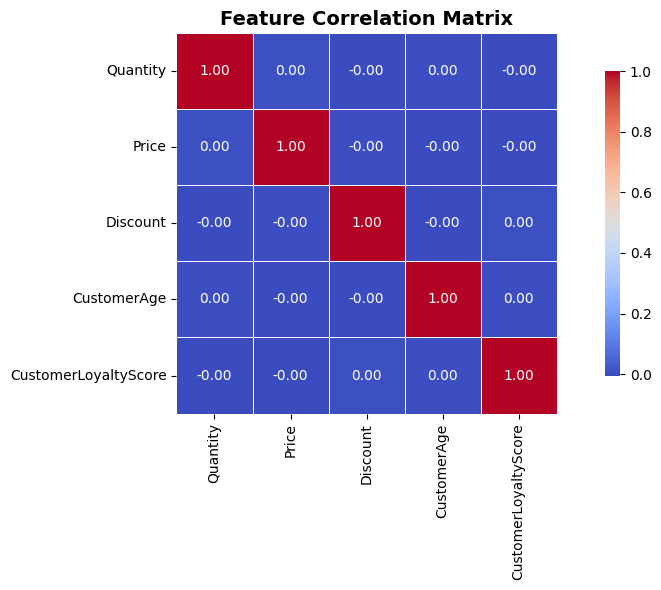

In [9]:
#heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

>The correlation analysis indicates that most numerical variables in the dataset have very weak relationships with each other, suggesting independent behavior among customer and transaction features.

C:\Users\wardo\AppData\Local\Temp\ipykernel_22360\770576662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ProductCategory', data=df, palette='Set2', edgecolor='black', linewidth=0.8)


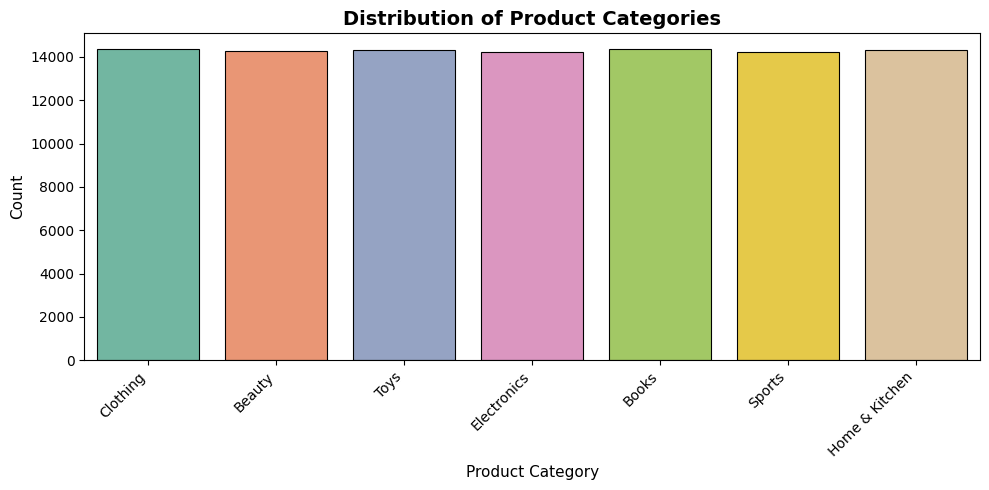

In [10]:
# 2. Product Category Countplot
plt.figure(figsize=(10,5))
sns.countplot(x='ProductCategory', data=df, palette='Set2', edgecolor='black', linewidth=0.8)
plt.title('Distribution of Product Categories', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 

>Product Category Distribution Insights

>The distribution of product categories is almost uniform across all categories.

>Clothing, Books, Toys, Electronics, Beauty, Sports, and Home & Kitchen have nearly equal transaction counts.

>No single category dominates the dataset, which indicates balanced customer purchasing behavior across categories.

>This balanced distribution is useful for unbiased analysis and machine learning modeling.

C:\Users\wardo\AppData\Local\Temp\ipykernel_22360\1398334644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PaymentMethod', data=df, palette='pastel', edgecolor='black', linewidth=0.8)


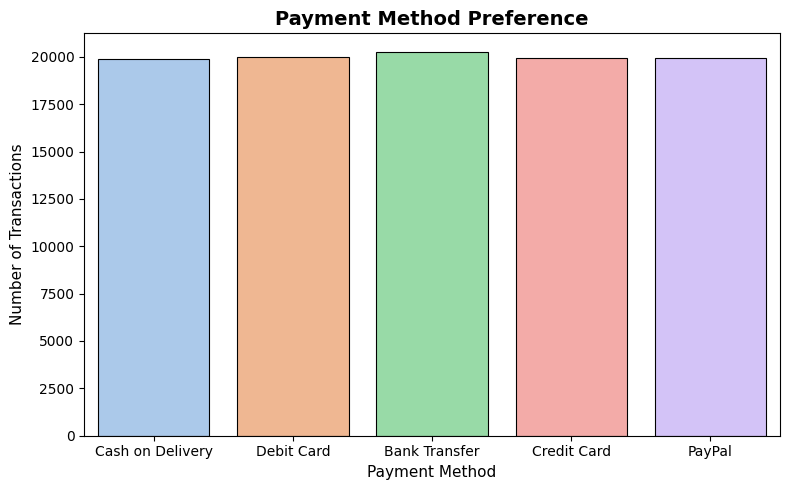

In [11]:
# 3. Payment Method Countplot
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', data=df, palette='pastel', edgecolor='black', linewidth=0.8)
plt.title('Payment Method Preference', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.tight_layout()

>Payment Method Preference Insights

>Customers are using all payment methods almost equally.

>Bank Transfer appears to have slightly higher usage compared to other payment methods.

>Cash on Delivery, Credit Card, Debit Card, and PayPal transactions are also consistently high.

>The dataset shows diversified payment behavior with no heavy dependency on a single payment method.

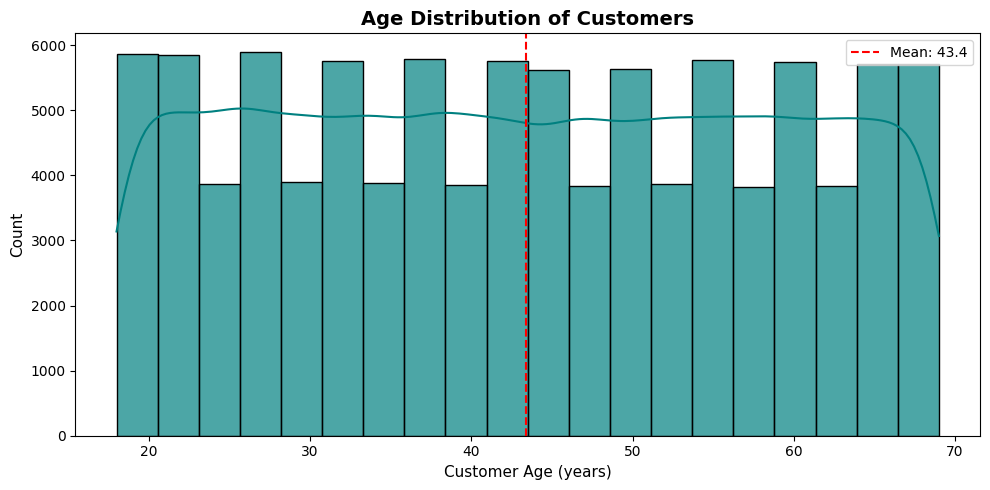

In [12]:
# 4. Customer Age Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['CustomerAge'], bins=20, kde=True, color='teal', alpha=0.7, edgecolor='black')
plt.title('Age Distribution of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Customer Age (years)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.axvline(df['CustomerAge'].mean(), color='red', linestyle='--', label=f'Mean: {df["CustomerAge"].mean():.1f}')
plt.legend()
plt.tight_layout()

> Customer Age Distribution Insights

>Customer ages are distributed fairly evenly between 18 and 70 years.

>The average customer age is approximately 43 years.

>There is no major age concentration or skewness observed in the dataset.

>The business appears to target customers from multiple age groups rather than focusing on a specific demographic.

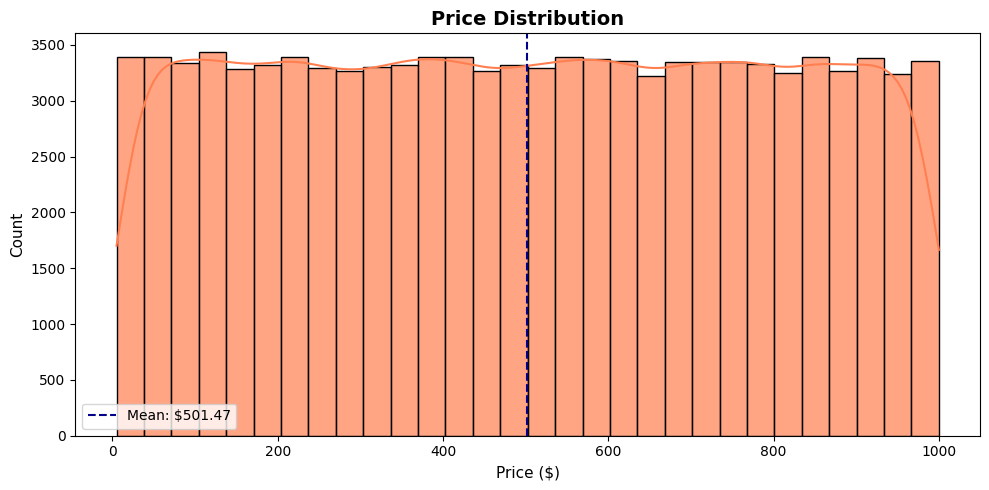

In [13]:
# 5. Price Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=30, kde=True, color='coral', alpha=0.7, edgecolor='black')
plt.title('Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.axvline(df['Price'].mean(), color='darkblue', linestyle='--', label=f'Mean: ${df["Price"].mean():.2f}')
plt.legend()
plt.tight_layout()

>Price Distribution Insights

>Product prices are spread almost uniformly between low-price and high-price ranges.

>The average product price is around $501.47.

>No strong skewness or abnormal clustering is observed in product pricing.

>The dataset includes products from multiple pricing segments, making it suitable for comprehensive sales and customer behavior analysis.

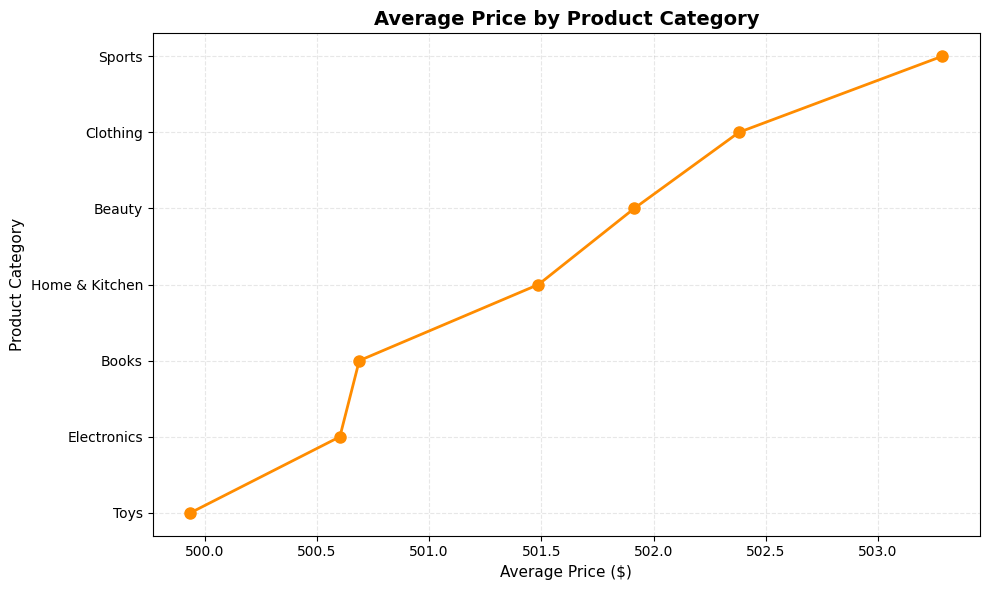

In [14]:
# Product Category vs Average Price
plt.figure(figsize=(10,6))
avg_price = df.groupby('ProductCategory')['Price'].mean().sort_values()
plt.plot(avg_price.values, avg_price.index, 'o-', color='darkorange', linewidth=2, markersize=8)
plt.title('Average Price by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Price ($)', fontsize=11)
plt.ylabel('Product Category', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

>Average Price by Product Category Insights

>Sports category has the highest average product price among all categories.

>Toys category has the lowest average product price.

>Most categories have average prices close to $500, indicating a balanced pricing structure across the platform.

>The small variation in average prices suggests that products are distributed evenly across categories without major pricing bias.

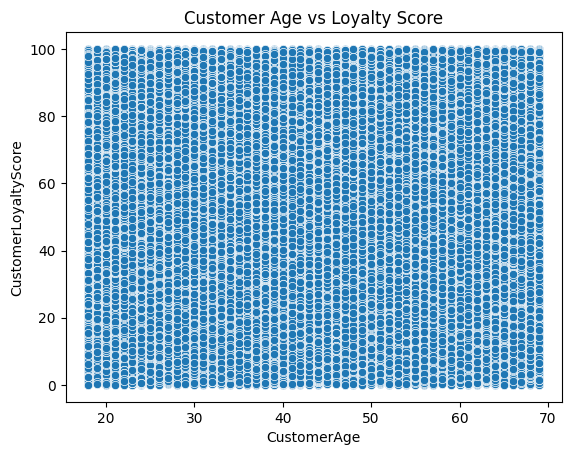

In [15]:
sns.scatterplot(x='CustomerAge',
        y='CustomerLoyaltyScore',
        data=df
    )

plt.title("Customer Age vs Loyalty Score")
plt.show()

>Customer Age vs Loyalty Score Insights

>There is no strong relationship between customer age and loyalty score.

>Customers of all age groups show both high and low loyalty scores.

>Loyalty behavior appears to be independent of customer age in this dataset.

>This suggests that factors other than age may influence customer loyalty more significantly.

C:\Users\wardo\AppData\Local\Temp\ipykernel_22360\2796103620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ProductCategory', y='Price', data=df, palette='pastel', width=0.6,


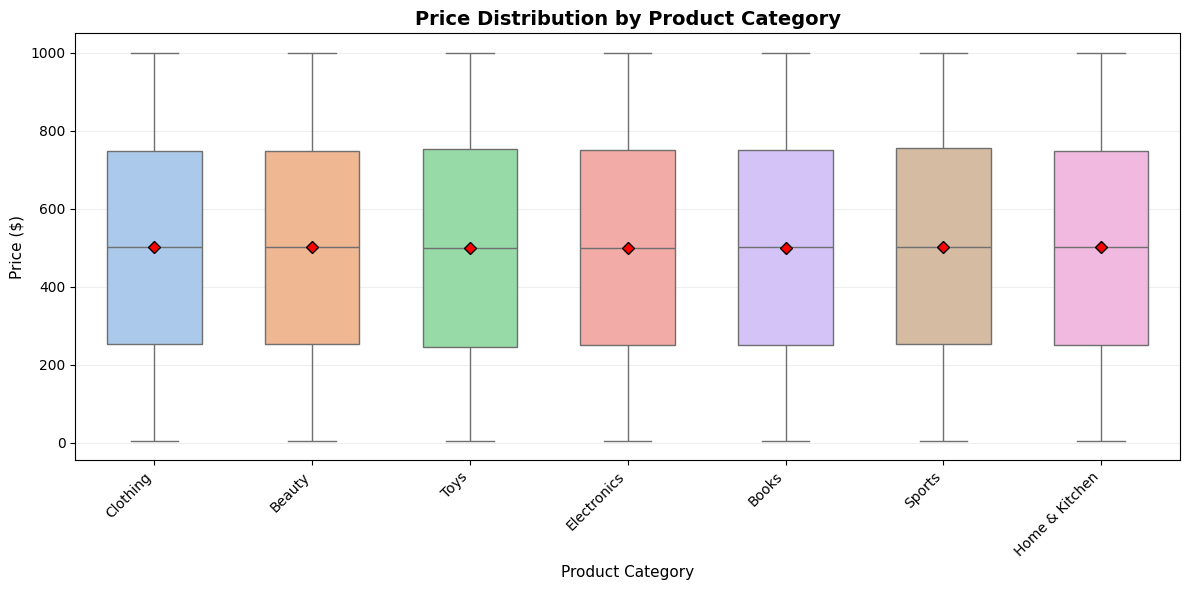

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='ProductCategory', y='Price', data=df, palette='pastel', width=0.6, 
    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":6})
plt.title('Price Distribution by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Price ($)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

>Price Distribution by Product Category Boxplot Insights

>All product categories show a very similar price distribution pattern.

>Median prices across categories are close to $500.

>The interquartile ranges are also similar, indicating consistent pricing spread across categories.

>No category shows extreme outliers or abnormal price behavior.

>The dataset appears well-balanced, which is beneficial for comparative analysis and machine learning tasks.



In [17]:
df.head()

,ProductCategory,Quantity,Price,Discount,TransactionDate,PaymentMethod,CustomerLocation,CustomerAge,CustomerGender,CustomerIncomeGroup,CustomerLoyaltyScore
0,Clothing,1,801.66,0.13,2023-12-22 10:35:26,Cash on Delivery,New Juan,46,Female,Medium,83.36
1,Beauty,1,225.03,0.06,2024-05-05 10:40:33,Debit Card,South Julie,59,Other,High,58.88
2,Toys,2,544.99,0.24,2023-12-04 05:22:59,Debit Card,West Carrieview,61,Female,High,53.99
3,Beauty,2,157.02,0.01,2024-01-02 11:11:00,Bank Transfer,Christianberg,69,Female,Low,11.73
4,Electronics,2,155.51,0.14,2024-06-18 01:01:29,Debit Card,South Williamhaven,29,Other,High,34.79


##  Overall Insights

>Customer purchasing activity is evenly distributed across all product categories, indicating balanced market demand without heavy dependency on a single category.

>The platform serves customers from diverse age groups, showing broad customer engagement across different demographics.

>Product pricing remains relatively stable across categories, suggesting a consistent pricing strategy throughout the business.

>Multiple payment methods are actively used by customers, which reflects flexibility and convenience in the purchasing process.

>Customer loyalty does not appear to be strongly influenced by age, indicating that loyalty behavior may depend more on user experience, product quality, or service factors.

>No strong correlation was observed among major numerical variables such as price, quantity, discount, and loyalty score, suggesting that customer purchasing behavior is influenced by multiple independent factors.

>The dataset is highly balanced with minimal bias in categories, pricing, and customer distribution, making it suitable for reliable exploratory analysis and machine learning implementation.

>Overall, the business demonstrates stable transactional behavior, diversified customer interaction, and consistent product engagement across the platform.